# Notebook 02 - 2D to 3D Inference Demo

The goals of this notebook are:

1. To obtain a real video from the dataset.

2. To use YOLOv8-Pose to extract 2D keypoints.

3. To pass the 2D keypoints to PoseFormerV2 to generate an estimated 3D pose.

4. To save the 3D results as a CSV file.

5. To visually draw a 2D skeleton and a 3D skeleton.

In [12]:
from pathlib import Path
import sys
import os

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]

PHASE2_DIR = PROJECT_ROOT / "phase2_3d_upgrade"
INFERENCE_DIR = PHASE2_DIR / "inference"
CHECKPOINT_DIR = PHASE2_DIR / "checkpoints"
OUTPUT_DIR = PHASE2_DIR / "outputs"
DEMO_FRAME_DIR = OUTPUT_DIR / "demo_3d_frames"
DEMO_CSV_DIR = OUTPUT_DIR / "demo_3d_csv"

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PHASE2_DIR))
sys.path.append(str(INFERENCE_DIR))

DEMO_FRAME_DIR.mkdir(parents=True, exist_ok=True)
DEMO_CSV_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Phase 2 dir:", PHASE2_DIR)
print("Demo frame dir:", DEMO_FRAME_DIR)
print("Demo csv dir:", DEMO_CSV_DIR)

Project root: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH
Phase 2 dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade
Demo frame dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\demo_3d_frames
Demo csv dir: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\demo_3d_csv


In [13]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import inspect

from ultralytics import YOLO
from inference.infer_3d_pose import PoseFormerV2Inferencer

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [14]:
raw_video_dir = PROJECT_ROOT / "data" / "1_raw_videos"

video_candidates = list(raw_video_dir.rglob("*.mp4"))

print("Total mp4 videos found:", len(video_candidates))

for i, path in enumerate(video_candidates[:10]):
    print(i, path)

VIDEO_PATH = video_candidates[0]

print("\nSelected video:")
print(VIDEO_PATH)

Total mp4 videos found: 5485
0 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0001.mp4
1 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0002.mp4
2 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0003.mp4
3 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0004.mp4
4 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0005.mp4
5 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0006_resized.mp4
6 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0007_resized.mp4
7 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0008_resized.mp4
8 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0009_resized.mp4
9 c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0010_resized.mp4

Selected video:
c:\U

In [15]:
YOLO_MODEL_PATH = PROJECT_ROOT / "yolov8m-pose.pt"
CHECKPOINT_PATH = CHECKPOINT_DIR / "1_3_27_48.7.bin"

device = "cuda" if torch.cuda.is_available() else "cpu"
yolo_device = 0 if torch.cuda.is_available() else "cpu"

print("YOLO model:", YOLO_MODEL_PATH)
print("PoseFormer checkpoint:", CHECKPOINT_PATH)
print("Device:", device)

yolo_model = YOLO(str(YOLO_MODEL_PATH))


def create_poseformer_inferencer(checkpoint_path):
    try:
        return PoseFormerV2Inferencer(
            checkpoint_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(
            ckpt_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(
            model_path=str(checkpoint_path),
            device=device
        )
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(str(checkpoint_path), device)
    except TypeError:
        pass

    try:
        return PoseFormerV2Inferencer(str(checkpoint_path))
    except TypeError:
        pass

    return PoseFormerV2Inferencer()


inferencer = create_poseformer_inferencer(CHECKPOINT_PATH)

print("YOLO and PoseFormerV2 loaded.")
print("Inferencer:", type(inferencer))

YOLO model: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\yolov8m-pose.pt
PoseFormer checkpoint: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints\1_3_27_48.7.bin
Device: cuda
Loaded PoseFormerV2 checkpoint:
  Path: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\checkpoints\1_3_27_48.7.bin
  Device: cuda
  Sequence length: 27
  Frame kept: 1
  Coeff kept: 3
YOLO and PoseFormerV2 loaded.
Inferencer: <class 'inference.infer_3d_pose.PoseFormerV2Inferencer'>


In [ ]:
COCO_EDGES = [
    (5, 6),
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (0, 5), (0, 6)
]

H36M_EDGES = [
    (0, 1), (1, 2), (2, 3),
    (0, 4), (4, 5), (5, 6),
    (0, 7), (7, 8), (8, 9), (9, 10),
    (8, 11), (11, 12), (12, 13),
    (8, 14), (14, 15), (15, 16)
]


def draw_2d_pose_on_image(image, keypoints):
    img = image.copy()

    for a, b in COCO_EDGES:
        pt1 = tuple(keypoints[a].astype(int))
        pt2 = tuple(keypoints[b].astype(int))
        cv2.line(img, pt1, pt2, (0, 255, 0), 2)

    for x, y in keypoints:
        cv2.circle(img, (int(x), int(y)), 4, (0, 0, 255), -1)

    return img


def coco2d_to_h36m_like_2d(coco_2d):
    """
    Convert COCO 17 joints to a H36M-like 17-joint layout for visualization.

    This is only for display alignment.
    It makes the 3D skeleton use the same joint order as H36M_EDGES.

    COCO:
        0 nose
        5 left shoulder, 6 right shoulder
        11 left hip, 12 right hip
        13 left knee, 14 right knee
        15 left ankle, 16 right ankle

    H36M-like:
        0 pelvis
        1 right hip
        2 right knee
        3 right ankle
        4 left hip
        5 left knee
        6 left ankle
        7 spine
        8 thorax
        9 neck
        10 head
        11 left shoulder
        12 left elbow
        13 left wrist
        14 right shoulder
        15 right elbow
        16 right wrist
    """

    coco_2d = np.asarray(coco_2d, dtype=np.float32)

    if coco_2d.shape != (17, 2):
        raise ValueError(f"Expected COCO 2D shape (17, 2), got {coco_2d.shape}")

    h36m = np.zeros((17, 2), dtype=np.float32)

    left_shoulder = coco_2d[5]
    right_shoulder = coco_2d[6]
    left_hip = coco_2d[11]
    right_hip = coco_2d[12]

    pelvis = (left_hip + right_hip) / 2.0
    thorax = (left_shoulder + right_shoulder) / 2.0
    spine = (pelvis + thorax) / 2.0
    neck = thorax
    head = coco_2d[0]

    h36m[0] = pelvis

    # right leg
    h36m[1] = right_hip
    h36m[2] = coco_2d[14]
    h36m[3] = coco_2d[16]

    # left leg
    h36m[4] = left_hip
    h36m[5] = coco_2d[13]
    h36m[6] = coco_2d[15]

    # body
    h36m[7] = spine
    h36m[8] = thorax
    h36m[9] = neck
    h36m[10] = head

    # left arm
    h36m[11] = left_shoulder
    h36m[12] = coco_2d[7]
    h36m[13] = coco_2d[9]

    # right arm
    h36m[14] = right_shoulder
    h36m[15] = coco_2d[8]
    h36m[16] = coco_2d[10]

    return h36m


def build_image_aligned_3d_pose(pose3d, keypoints_2d):
    """
    Build a display-friendly 3D skeleton that follows the person in the image.

    Important:
        This is for visualization only.

    X comes from 2D image x.
    Z comes from 2D image y, inverted so upward is positive.
    Y comes from estimated 3D depth.

    This makes the 3D skeleton match the body pose seen in the video frame.
    """

    pose3d = np.asarray(pose3d, dtype=np.float32)
    keypoints_2d = np.asarray(keypoints_2d, dtype=np.float32)

    if pose3d.shape != (17, 3):
        raise ValueError(f"Expected 3D pose shape (17, 3), got {pose3d.shape}")

    if keypoints_2d.shape != (17, 2):
        raise ValueError(f"Expected 2D keypoints shape (17, 2), got {keypoints_2d.shape}")

    # Convert COCO 2D to H36M-like 2D order
    h36m_2d = coco2d_to_h36m_like_2d(keypoints_2d)

    xs = h36m_2d[:, 0]
    ys = h36m_2d[:, 1]

    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()

    center_x = (min_x + max_x) / 2.0
    center_y = (min_y + max_y) / 2.0

    width = max_x - min_x
    height = max_y - min_y

    scale = max(width, height, 1e-6)

    # X follows image left-right
    x_display = (xs - center_x) / scale

    # Z follows image vertical direction, but image y goes downward
    z_display = -(ys - center_y) / scale

    # Depth from PoseFormerV2.
    # Use raw 3D depth, center and scale it so it does not dominate the plot.
    depth = pose3d[:, 2].copy()
    depth = depth - depth.mean()

    depth_std = depth.std()
    if depth_std < 1e-6:
        depth_std = 1.0

    y_display = depth / depth_std

    # Reduce depth range so image pose remains visually dominant
    y_display = y_display * 0.25

    visual = np.stack([x_display, y_display, z_display], axis=1).astype(np.float32)

    return visual


def set_axes_equal_3d(ax, pose):
    x = pose[:, 0]
    y = pose[:, 1]
    z = pose[:, 2]

    max_range = np.array([
        x.max() - x.min(),
        y.max() - y.min(),
        z.max() - z.min()
    ]).max()

    if max_range <= 1e-6:
        max_range = 1.0

    mid_x = (x.max() + x.min()) * 0.5
    mid_y = (y.max() + y.min()) * 0.5
    mid_z = (z.max() + z.min()) * 0.5

    radius = max_range * 0.60

    ax.set_xlim(mid_x - radius, mid_x + radius)
    ax.set_ylim(mid_y - radius, mid_y + radius)
    ax.set_zlim(mid_z - radius, mid_z + radius)


def plot_image_aligned_3d_pose(pose3d, keypoints_2d, title="Image-aligned Estimated 3D Pose"):
    visual = build_image_aligned_3d_pose(pose3d, keypoints_2d)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    xs = visual[:, 0]
    ys = visual[:, 1]
    zs = visual[:, 2]

    ax.scatter(xs, ys, zs, s=35)

    for a, b in H36M_EDGES:
        ax.plot(
            [xs[a], xs[b]],
            [ys[a], ys[b]],
            [zs[a], zs[b]],
            linewidth=2
        )

    ax.set_title(title)
    ax.set_xlabel("X from 2D image")
    ax.set_ylabel("Y depth from 3D")
    ax.set_zlabel("Z height from 2D image")

    set_axes_equal_3d(ax, visual)

    # View from front so it follows the image pose.
    # This makes the skeleton look like the person in the video frame.
    ax.view_init(elev=8, azim=-90)

    plt.show()

In [17]:
MAX_FRAMES = 180

cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_PATH}")

rows = []
first_debug_frame = None
first_debug_kpts = None
first_debug_pose3d = None

frame_idx = 0
valid_2d_count = 0
valid_3d_count = 0

while cap.isOpened() and frame_idx < MAX_FRAMES:
    success, frame = cap.read()

    if not success:
        break

    results = yolo_model(frame, verbose=False, device=yolo_device)

    keypoints = None

    if results and results[0].keypoints is not None and len(results[0].keypoints.xy) > 0:
        keypoints = results[0].keypoints.xy[0].cpu().numpy().astype(np.float32)

    if keypoints is not None and keypoints.shape == (17, 2):
        valid_2d_count += 1

        pose3d = inferencer.add_and_predict(keypoints)

        if pose3d is not None:
            pose3d = np.asarray(pose3d, dtype=np.float32)

            if pose3d.shape == (17, 3):
                valid_3d_count += 1

                row = {"frame": frame_idx}

                for j in range(17):
                    row[f"x{j}"] = float(pose3d[j, 0])
                    row[f"y{j}"] = float(pose3d[j, 1])
                    row[f"z{j}"] = float(pose3d[j, 2])

                rows.append(row)

                if first_debug_frame is None:
                    first_debug_frame = frame.copy()
                    first_debug_kpts = keypoints.copy()
                    first_debug_pose3d = pose3d.copy()

    frame_idx += 1

cap.release()

print("Processed frames:", frame_idx)
print("Valid 2D frames:", valid_2d_count)
print("Valid 3D frames:", valid_3d_count)
print("Rows collected:", len(rows))

Processed frames: 90
Valid 2D frames: 89
Valid 3D frames: 63
Rows collected: 63


In [18]:
video_stem = VIDEO_PATH.stem
output_csv = DEMO_CSV_DIR / f"{video_stem}_estimated_3d.csv"

df_3d = pd.DataFrame(rows)
df_3d.to_csv(output_csv, index=False)

print("Saved 3D CSV to:")
print(output_csv)

print("CSV shape:", df_3d.shape)
df_3d.head()

Saved 3D CSV to:
c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\demo_3d_csv\B_D_0001_estimated_3d.csv
CSV shape: (63, 52)


,frame,x0,y0,z0,x1,y1,z1,x2,y2,z2,...,z13,x14,y14,z14,x15,y15,z15,x16,y16,z16
0,26,0.000562,-0.001205,-0.001787,0.078131,0.016229,-0.005386,0.010961,0.362192,0.115992,...,0.239350,0.340093,-0.187749,0.053208,0.380852,0.087283,0.033040,0.334589,0.232953,0.174439
1,27,0.000619,-0.001267,-0.002041,0.080107,0.016536,0.006249,0.005769,0.367682,0.114752,...,0.210314,0.320296,-0.216248,0.041651,0.351087,0.055318,0.032390,0.296317,0.198603,0.160494
2,28,0.000767,-0.000697,-0.002494,0.082412,0.015146,0.018761,-0.009682,0.366762,0.112303,...,0.181863,0.302300,-0.242241,0.036308,0.319420,0.023813,0.039295,0.261654,0.169603,0.155712
3,29,0.000481,-0.000387,-0.002558,0.083129,0.014359,0.027738,-0.024221,0.369173,0.103322,...,0.159269,0.280203,-0.270048,0.034080,0.288535,-0.007648,0.046610,0.227270,0.133830,0.155869
4,30,0.000208,0.000002,-0.002855,0.080576,0.010706,0.036269,-0.051212,0.364520,0.098933,...,0.132132,0.253946,-0.296120,0.030519,0.254271,-0.039223,0.054782,0.195688,0.101110,0.156157


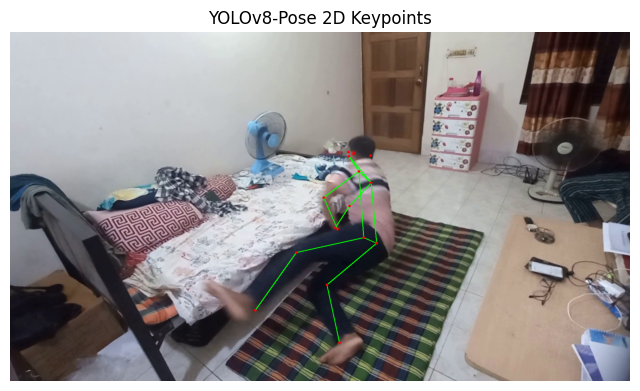

In [19]:
if first_debug_frame is None:
    print("No debug frame available.")
else:
    img_2d = draw_2d_pose_on_image(first_debug_frame, first_debug_kpts)
    img_2d_rgb = cv2.cvtColor(img_2d, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_2d_rgb)
    plt.title("YOLOv8-Pose 2D Keypoints")
    plt.axis("off")
    plt.show()

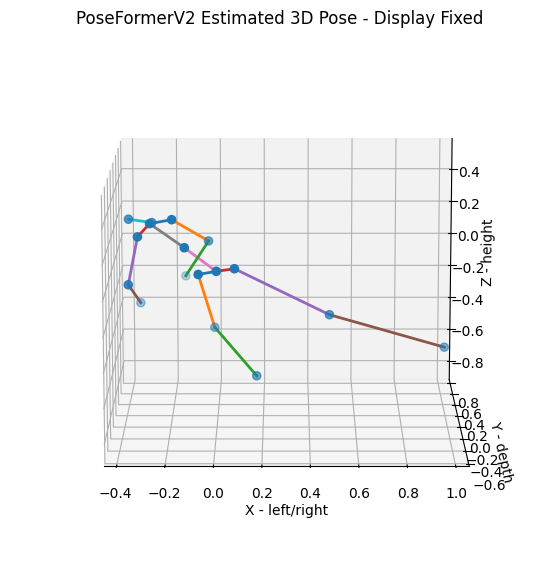

In [ ]:
if first_debug_pose3d is None:
    print("No 3D pose available.")
else:
    plot_image_aligned_3d_pose(
        first_debug_pose3d,
        first_debug_kpts,
        "Image-aligned Estimated 3D Skeleton"
    )

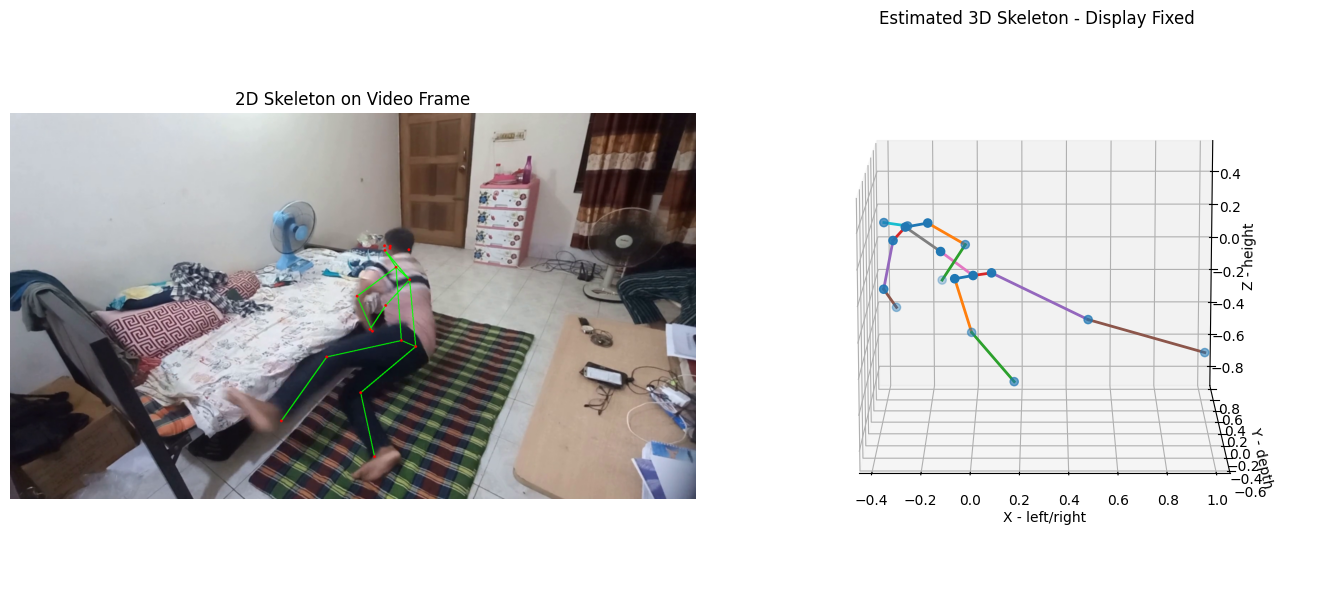

In [ ]:
if first_debug_frame is not None and first_debug_pose3d is not None:
    img_2d = draw_2d_pose_on_image(first_debug_frame, first_debug_kpts)
    img_2d_rgb = cv2.cvtColor(img_2d, cv2.COLOR_BGR2RGB)

    visual = build_image_aligned_3d_pose(first_debug_pose3d, first_debug_kpts)

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(img_2d_rgb)
    ax1.set_title("2D Skeleton on Video Frame")
    ax1.axis("off")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    xs = visual[:, 0]
    ys = visual[:, 1]
    zs = visual[:, 2]

    ax2.scatter(xs, ys, zs, s=35)

    for a, b in H36M_EDGES:
        ax2.plot(
            [xs[a], xs[b]],
            [ys[a], ys[b]],
            [zs[a], zs[b]],
            linewidth=2
        )

    ax2.set_title("Image-aligned Estimated 3D Skeleton")
    ax2.set_xlabel("X from 2D image")
    ax2.set_ylabel("Y depth from 3D")
    ax2.set_zlabel("Z height from 2D image")

    set_axes_equal_3d(ax2, visual)

    # Front view: makes 3D skeleton follow image pose
    ax2.view_init(elev=8, azim=-90)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for side-by-side visualization.")

In [22]:
print("Demo completed.")
print("Video:", VIDEO_PATH)
print("Generated 3D rows:", len(df_3d))
print("Output CSV:", output_csv)

if len(df_3d) > 0:
    print("The 2D-to-3D pipeline works on this video.")
else:
    print("No 3D pose was generated. Check YOLO detections or PoseFormerV2 buffer requirements.")

Demo completed.
Video: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\data\1_raw_videos\Fall\f_raw_b_1\B_D_0001.mp4
Generated 3D rows: 63
Output CSV: c:\Users\ASUS\Downloads\3D_Human_Pose_NCKH\phase2_3d_upgrade\outputs\demo_3d_csv\B_D_0001_estimated_3d.csv
The 2D-to-3D pipeline works on this video.
